# Disk Identification — PopIII Star Formation Simulation



## Method summary

The disk is identified using a **hybrid geometric + kinematic** approach applied to gas particles in each snapshot.

### Step 1 — Find the disk center and rotation axis
The center of mass (`com`) is computed from sink particles if any exist, otherwise from the densest gas particle. The rotation axis (`L_hat`) is the normalized total angular momentum vector of gas within a search sphere of radius `r_search_kpc`, computed in the COM velocity frame.

### Step 2 — Project to cylindrical coordinates
All gas particles are projected into a cylindrical frame aligned with `L_hat`, giving each particle a cylindrical radius `r_cyl`, height `z`, and azimuthal velocity `v_phi` (positive = co-rotating).

### Step 3 — Geometric pre-selection
Candidate disk particles must satisfy:
- `r_cyl < r_max` — within the outer disk boundary
- `|z| / r_cyl < aspect_ratio` — close to the equatorial plane
- `rho > rho_threshold` — dense enough to be disk gas, not diffuse envelope

### Step 4 — Kinematic filter
From the geometric candidates, infalling streamers are removed by requiring:
- `v_phi > 0` — co-rotating with the disk
- `v_phi / v_K > f_kep` — rotationally supported (relaxed threshold to retain sub-Keplerian outer disk)

where `v_K = sqrt(G * M_enc / r_cyl)` and `M_enc` includes all sink masses plus enclosed gas mass interior to `r_cyl`.

### Step 5 — Extend to bounding cylinder
The kinematic selection can leave holes where gas is slightly sub-threshold. The final disk is taken to be **all gas within the bounding cylinder** of the kinematic selection:
- `r_cyl < R_bound` and `|z| < H_bound`

where `R_bound` and `H_bound` are the maximum `r_cyl` and `|z|` of the kinematic disk particles.

### Why this works across all simulation phases
| Phase | Center | `M_enc` | Notes |
|---|---|---|---|
| Pre-stellar (no sinks) | Densest gas particle | Gas only | Rotating dense core identified by kinematics |
| Single star | Sink CoM | Star + gas | Star mass dominates at small radii |
| Fragmented disk | CoM of all sinks | All sinks + gas | Dense inter-sink gas naturally included |

### Key tunable parameters
| Parameter | Default | Effect |
|---|---|---|
| `r_search_kpc` | `1e-5` (~2000 AU) | Aperture for computing `L_hat` and COM velocity |
| `r_max_kpc` | `1e-5` (~2000 AU) | Outer disk boundary |
| `rho_threshold_cgs` | `1e-15` g/cm³ | Density floor; tune using the rotation curve plot |
| `aspect_ratio` | `0.3` | Geometric thinness: `|z|/r_cyl < aspect_ratio` |
| `f_kep` | `0.3` | Rotational support fraction; tune using rotation curve plot |


In [29]:
from generic_utils.fire_utils import *
from generic_utils.constants import *        # re-import for plain float Msun, kpc, AU, G
from hybrid_sims_utils.read_snap import *
from movie_utils.rotation import *

from meshoid import Meshoid
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colors
from matplotlib.colors import LogNorm
import colorcet as cc

import numpy as np
import glob
import os
import pickle
from tqdm import tqdm


## Load a single snapshot for development

In [30]:
path    = "/mnt/home/skhullar/ceph/projects/SFIRE/m12f/"
#sim     = "output_new_jeans_refinement"
sim    = "output_cutout"
snap_num = 150

gas_fields = ["Masses", "Coordinates", "SmoothingLength",
              "Velocities", "Temperature", "Density", "ParticleIDs"]

header, pdata, stardata, fire_stardata, _, _ = get_snap_data_hybrid(
    sim, path, snap_num, snapshot_suffix='', snapdir=False,
    refinement_tag=False, verbose=True, custom_gas_fields=gas_fields)
header, pdata, stardata, fire_stardata = convert_units_to_physical(
    header, pdata, stardata, fire_stardata)

n_stars = len(stardata['Masses']) if stardata else 0
print(f"Snap {snap_num}  |  scale factor a = {header['Time']:.6f}")
print(f"Gas particles : {len(pdata['Masses'])}")
print(f"Sink particles: {n_stars}")
if n_stars > 0:
    print(f"Sink masses   : {stardata['Masses'].min()*1e10:.4f} – {stardata['Masses'].max()*1e10:.4f} Msun")


Reading file: /mnt/home/skhullar/ceph/projects/SFIRE/m12f/output_cutout/snapshot_150.hdf5
Snap 150  |  scale factor a = 0.045475
Gas particles : 442445
Sink particles: 3
Sink masses   : 0.4007 – 5.0001 Msun


## Helper functions

All unit conversions to CGS are done **inside** these functions.
Input data is expected in post-`convert_units_to_physical` code units:
- Coordinates: kpc
- Velocities: km/s
- Masses: 1e10 M☉
- Density: 1e10 M☉/kpc³


In [31]:
# ── Physical constants (from generic_utils.constants, all CGS) ────────────────
# kpc  = 3.086e21 cm
# AU   = 1.496e13 cm
# Msun = 1.989e33 g
# G    = 6.67e-8  CGS
# These are imported as plain floats via `from generic_utils.constants import *`


def find_center(pdata, stardata):
    """
    Disk center: mass-weighted CoM of sinks if any exist, else densest gas particle.
    Returns com in kpc (code units after convert_units_to_physical).
    """
    if stardata and len(stardata.get('Masses', [])) > 0:
        com = (np.sum(stardata['Coordinates'] * stardata['Masses'][:, None], axis=0)
               / np.sum(stardata['Masses']))
    else:
        idx = np.argmax(pdata['Density'])
        com = pdata['Coordinates'][idx]
    return com


def get_disk_axis(gas_pos_kpc, gas_vel_kms, gas_masses_Msun, r_search_kpc):
    """
    Compute disk rotation axis L_hat from gas within r_search_kpc of origin.
    Inputs are centered on com (gas_pos_kpc = coords - com) and in COM frame.
    """
    dists = np.linalg.norm(gas_pos_kpc, axis=1)
    mask  = dists < r_search_kpc
    if mask.sum() < 4:
        print("Warning: fewer than 4 particles in r_search, defaulting L_hat = z")
        return np.array([0., 0., 1.])

    pos_cm  = gas_pos_kpc[mask]  * kpc        # kpc → cm
    vel_cms = gas_vel_kms[mask]  * 1e5        # km/s → cm/s
    m_g     = gas_masses_Msun[mask] * Msun    # Msun → g

    L     = np.sum(m_g[:, None] * np.cross(pos_cm, vel_cms), axis=0)
    L_mag = np.linalg.norm(L)
    if L_mag > 0:
        return L / L_mag
    else:
        print("Warning: L = 0, defaulting L_hat = z")
        return np.array([0., 0., 1.])


def cylindrical_coords(pos_kpc, vel_kms, L_hat):
    """
    Project positions and velocities into cylindrical coordinates aligned with L_hat.

    Returns
    -------
    r_cyl_kpc : cylindrical radius (distance from rotation axis) [kpc]
    z_kpc     : height along L_hat (signed) [kpc]
    v_phi_kms : azimuthal velocity, positive = co-rotating with L_hat [km/s]
    v_r_kms   : radial velocity in disk plane, positive = outward [km/s]
    v_z_kms   : velocity along L_hat [km/s]
    """
    z_kpc    = pos_kpc @ L_hat                          # scalar projection
    v_z_kms  = vel_kms @ L_hat

    r_perp   = pos_kpc - z_kpc[:, None] * L_hat        # vector in disk plane
    r_cyl_kpc = np.linalg.norm(r_perp, axis=1)

    safe_r   = np.maximum(r_cyl_kpc, 1e-30)
    e_r      = r_perp / safe_r[:, None]                 # radial unit vector
    e_phi    = np.cross(L_hat, e_r)                     # azimuthal unit vector (RHR)

    v_r_kms  = np.einsum('ij,ij->i', vel_kms, e_r)
    v_phi_kms = np.einsum('ij,ij->i', vel_kms, e_phi)

    return r_cyl_kpc, z_kpc, v_phi_kms, v_r_kms, v_z_kms


def compute_M_enc(r_cyl_kpc, gas_masses_Msun, M_stars_Msun):
    """
    Enclosed mass interior to each particle's cylindrical radius.
    M_enc[i] = M_stars + sum(gas_mass[j] for j where r_cyl[j] < r_cyl[i]).
    Vectorized via argsort + cumsum; exclusive of particle i itself.

    Returns M_enc in grams.
    """
    sort_idx      = np.argsort(r_cyl_kpc)
    sorted_masses = gas_masses_Msun[sort_idx]

    # cumulative mass EXCLUDING current particle (shift by 1)
    cumsum        = np.concatenate([[0.0], np.cumsum(sorted_masses[:-1])])
    M_enc_sorted  = (M_stars_Msun + cumsum) * Msun   # → grams

    M_enc = np.empty(len(r_cyl_kpc))
    M_enc[sort_idx] = M_enc_sorted
    return M_enc



def extend_disk_to_bounds(pdata, is_disk_kinematic, r_cyl_kpc, z_kpc,
                           percentile=100):
    """
    Extend the kinematically identified disk to fill its bounding cylinder,
    eliminating holes due to sub-Keplerian or low-v_phi gas.

    The bounding cylinder is defined by the extent of the kinematic disk:
      r_cyl < R_bound  AND  |z| < H_bound

    where R_bound and H_bound are the `percentile`-th percentile of r_cyl and |z|
    among kinematic disk particles (use 100 for strict bounding box; lower values
    are more robust to outliers).

    Parameters
    ----------
    is_disk_kinematic : bool array (N_gas,)
    r_cyl_kpc         : cylindrical radii [kpc]
    z_kpc             : heights along L_hat [kpc]
    percentile        : percentile used to define R_bound and H_bound (default 100)

    Returns
    -------
    is_disk_bounded   : bool array (N_gas,) — all gas within the bounding cylinder
    R_bound_kpc       : bounding cylindrical radius [kpc]
    H_bound_kpc       : bounding half-thickness [kpc]
    """
    if is_disk_kinematic.sum() == 0:
        return is_disk_kinematic.copy(), 0.0, 0.0

    R_bound_kpc = np.percentile(r_cyl_kpc[is_disk_kinematic], percentile)
    H_bound_kpc = np.percentile(np.abs(z_kpc[is_disk_kinematic]), percentile)

    is_disk_bounded = (r_cyl_kpc < R_bound_kpc) & (np.abs(z_kpc) < H_bound_kpc)

    return is_disk_bounded, R_bound_kpc, H_bound_kpc

def identify_disk(pdata, stardata,
                  r_search_kpc      = 1e-5,
                  r_max_kpc         = 1e-5,
                  rho_threshold_cgs = 1e-15,
                  aspect_ratio      = 0.3,
                  f_kep             = 0.3,
                  use_bounds        = True,
                  bounds_percentile = 100):
    """
    Identify disk gas particles using a hybrid geometric + kinematic criterion.

    Parameters
    ----------
    pdata / stardata       : as returned by get_snap_data_hybrid + convert_units_to_physical
    r_search_kpc           : sphere radius used to compute COM velocity and L_hat [kpc]
    r_max_kpc              : maximum cylindrical radius for disk candidates [kpc]
    rho_threshold_cgs      : minimum density to be considered disk gas [g/cm^3]
    aspect_ratio           : maximum |z| / r_cyl (geometric thinness)
    f_kep                  : minimum v_phi / v_K (rotational support fraction)

    Returns
    -------
    is_disk     : bool array (N_gas,)
    com         : disk center [kpc]
    L_hat       : disk rotation axis unit vector
    r_cyl_kpc   : cylindrical radii of all gas particles [kpc]
    z_kpc       : heights of all gas particles along L_hat [kpc]
    v_phi_kms   : azimuthal velocities [km/s]
    v_K_kms     : Keplerian velocities at each particle's r_cyl [km/s]
    """
    # ── Center ────────────────────────────────────────────────────────────────
    com         = find_center(pdata, stardata)
    gas_pos_kpc = pdata['Coordinates'] - com
    gas_dists   = np.linalg.norm(gas_pos_kpc, axis=1)

    gas_masses_Msun = pdata['Masses'] * 1e10   # code → Msun

    # ── COM velocity (from gas within r_search) ───────────────────────────────
    search_mask = gas_dists < r_search_kpc
    if search_mask.sum() > 0:
        com_vel = (np.sum(pdata['Velocities'][search_mask]
                          * gas_masses_Msun[search_mask, None], axis=0)
                   / np.sum(gas_masses_Msun[search_mask]))
    else:
        com_vel = np.zeros(3)

    gas_vel_com = pdata['Velocities'] - com_vel   # km/s, COM frame

    # ── Disk axis ─────────────────────────────────────────────────────────────
    L_hat = get_disk_axis(gas_pos_kpc, gas_vel_com, gas_masses_Msun, r_search_kpc)

    # ── Cylindrical coordinates ───────────────────────────────────────────────
    r_cyl_kpc, z_kpc, v_phi_kms, v_r_kms, v_z_kms = cylindrical_coords(
        gas_pos_kpc, gas_vel_com, L_hat)

    # ── Enclosed mass → Keplerian velocity ───────────────────────────────────
    M_stars_Msun = (np.sum(stardata['Masses']) * 1e10
                    if stardata and len(stardata.get('Masses', [])) > 0 else 0.0)
    M_enc_g   = compute_M_enc(r_cyl_kpc, gas_masses_Msun, M_stars_Msun)

    r_cyl_cm  = np.maximum(r_cyl_kpc * kpc, 1e-10)   # cm
    v_K_cms   = np.sqrt(G * M_enc_g / r_cyl_cm)
    v_K_kms   = v_K_cms / 1e5

    # ── Density in g/cm^3 ────────────────────────────────────────────────────
    rho_gcm3  = pdata['Density'] * 1e10 * Msun / kpc**3

    # ── Stage 1: Geometric pre-selection ─────────────────────────────────────
    safe_r_cyl   = np.maximum(r_cyl_kpc, 1e-30)
    is_within    = r_cyl_kpc < r_max_kpc
    is_equatorial = np.abs(z_kpc) / safe_r_cyl < aspect_ratio
    is_dense     = rho_gcm3 > rho_threshold_cgs

    # ── Stage 2: Kinematic filter ─────────────────────────────────────────────
    is_corotating = v_phi_kms > 0
    is_supported  = v_phi_kms / np.maximum(v_K_kms, 1e-10) > f_kep

    is_disk = is_within & is_equatorial & is_dense & is_corotating & is_supported

    # ── Extend to bounding cylinder (fills holes) ───────────────────────────
    if use_bounds:
        is_disk, R_bound, H_bound = extend_disk_to_bounds(
            pdata, is_disk, r_cyl_kpc, z_kpc, percentile=bounds_percentile)

    return is_disk, com, L_hat, r_cyl_kpc, z_kpc, v_phi_kms, v_K_kms


def compute_disk_properties(pdata, stardata, is_disk, r_cyl_kpc, z_kpc, L_hat):
    """Compute summary properties of the identified disk."""
    gas_masses_Msun = pdata['Masses'] * 1e10
    disk_masses     = gas_masses_Msun[is_disk]
    M_disk          = disk_masses.sum()

    n_stars   = len(stardata['Masses']) if stardata and len(stardata.get('Masses', [])) > 0 else 0
    M_stars   = np.sum(stardata['Masses']) * 1e10 if n_stars > 0 else 0.0

    if is_disk.sum() > 0:
        R_disk_kpc = np.percentile(r_cyl_kpc[is_disk], 90)
        H_disk_kpc = np.percentile(np.abs(z_kpc[is_disk]), 90)
    else:
        R_disk_kpc = H_disk_kpc = 0.0

    return {
        'M_disk_Msun'     : M_disk,
        'M_stars_Msun'    : M_stars,
        'R_disk_kpc'      : R_disk_kpc,
        'R_disk_AU'       : R_disk_kpc * kpc / AU,
        'H_disk_kpc'      : H_disk_kpc,
        'H_disk_AU'       : H_disk_kpc * kpc / AU,
        'H_over_R'        : H_disk_kpc / R_disk_kpc if R_disk_kpc > 0 else 0.0,
        'n_disk_particles': int(is_disk.sum()),
        'n_stars'         : n_stars,
        'L_hat'           : L_hat,
    }


## Single-snapshot test

**Parameters to tune visually:**
- `r_search_kpc`: sphere for computing L_hat (set to ~disk diameter)
- `r_max_kpc`: outer disk boundary
- `rho_threshold_cgs`: density floor in g/cm³ (from CalcQuants profile: disk gas ~10⁻¹⁵–10⁻¹² g/cm³)
- `aspect_ratio`: geometric thinness |z|/r_cyl
- `f_kep`: fraction of Keplerian velocity (0.3 is relaxed to capture sub-Keplerian outer disk)


In [32]:
# ── Tunable parameters ───────────────────────────────────────────────────────
r_search_kpc      = 1e-5      # ~2000 AU — sphere for computing L_hat and COM velocity
r_max_kpc         = 1e-5      # ~2000 AU — outer disk boundary
rho_threshold_cgs = 1e-15     # g/cm^3  — tune this! see rotation curve plot below
aspect_ratio      = 0.3       # |z|/r_cyl < this
f_kep             = 0.3       # v_phi / v_K > this

# ── Run ──────────────────────────────────────────────────────────────────────
is_disk, com, L_hat, r_cyl_kpc, z_kpc, v_phi_kms, v_K_kms = identify_disk(
    pdata, stardata,
    r_search_kpc      = r_search_kpc,
    r_max_kpc         = r_max_kpc,
    rho_threshold_cgs = rho_threshold_cgs,
    aspect_ratio      = aspect_ratio,
    f_kep             = f_kep,
    use_bounds        = True,     # extend kinematic estimate to bounding cylinder
    bounds_percentile = 100,      # 100 = strict bounding box; lower = more robust
)

props = compute_disk_properties(pdata, stardata, is_disk, r_cyl_kpc, z_kpc, L_hat)

# Also show the kinematic-only count for comparison
is_disk_kinematic, _, _, _, _, _, _ = identify_disk(
    pdata, stardata,
    r_search_kpc=r_search_kpc, r_max_kpc=r_max_kpc,
    rho_threshold_cgs=rho_threshold_cgs, aspect_ratio=aspect_ratio,
    f_kep=f_kep, use_bounds=False)
print(f"Kinematic disk  : {is_disk_kinematic.sum()} particles")
print(f"Bounded disk    : {props['n_disk_particles']} particles  (bounding cylinder)")
print(f"Disk particles : {props['n_disk_particles']}")
print(f"Disk mass      : {props['M_disk_Msun']:.3f} M☉")
print(f"Stellar mass   : {props['M_stars_Msun']:.4f} M☉")
print(f"Disk radius    : {props['R_disk_AU']:.1f} AU  (90th percentile of r_cyl)")
print(f"Scale height   : {props['H_disk_AU']:.1f} AU  (90th percentile of |z|)")
print(f"H / R          : {props['H_over_R']:.3f}")
print(f"Rotation axis  : {L_hat}")


Kinematic disk  : 25659 particles
Bounded disk    : 36732 particles  (bounding cylinder)
Disk particles : 36732
Disk mass      : 61.255 M☉
Stellar mass   : 8.5288 M☉
Disk radius    : 1716.6 AU  (90th percentile of r_cyl)
Scale height   : 383.1 AU  (90th percentile of |z|)
H / R          : 0.223
Rotation axis  : [0.03096373 0.12513331 0.99165665]


## Rotation curve diagnostic

Use this plot to tune `rho_threshold_cgs` and `f_kep`.
Dense disk gas should sit near or below the Keplerian curve; infalling gas typically has low v_phi.
The horizontal dashed line shows `f_kep × v_K`; particles above it (in the colored scatter) are selected as disk.


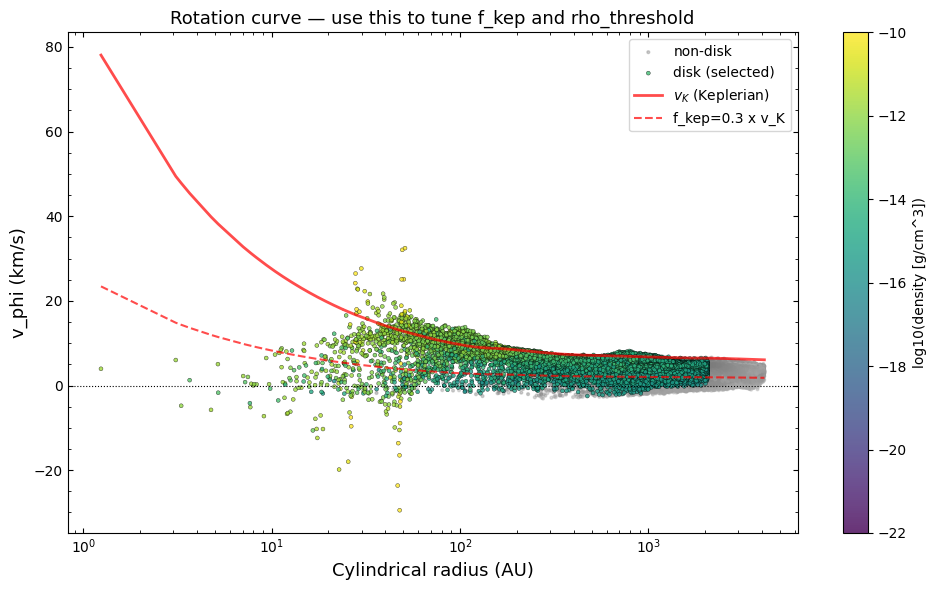

In [33]:
# Only show particles within 2× r_max for context
rho_gcm3  = pdata['Density'] * 1e10 * Msun / kpc**3
gas_dists = np.linalg.norm(pdata['Coordinates'] - com, axis=1)
plot_mask = gas_dists < r_max_kpc * 2

r_plot_AU   = r_cyl_kpc[plot_mask] * kpc / AU
v_phi_plot  = v_phi_kms[plot_mask]
v_K_plot    = v_K_kms[plot_mask]
rho_plot    = rho_gcm3[plot_mask]
disk_plot   = is_disk[plot_mask]

# Sort by r for Keplerian curve line
sort_r = np.argsort(r_plot_AU)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    r_plot_AU[~disk_plot], v_phi_plot[~disk_plot],
    c=np.log10(np.maximum(rho_plot[~disk_plot], 1e-30)),
    cmap='Greys', s=4, alpha=0.4, vmin=-22, vmax=-10, label='non-disk'
)
sc2 = ax.scatter(
    r_plot_AU[disk_plot], v_phi_plot[disk_plot],
    c=np.log10(np.maximum(rho_plot[disk_plot], 1e-30)),
    cmap='viridis', s=8, alpha=0.8, vmin=-22, vmax=-10, label='disk (selected)',
    edgecolors='k', linewidths=0.3
)
plt.colorbar(sc2, label='log10(density [g/cm^3])')

ax.plot(r_plot_AU[sort_r], v_K_plot[sort_r],
        'r-', lw=2, label='$v_K$ (Keplerian)', zorder=5, alpha=0.7)
ax.plot(r_plot_AU[sort_r], f_kep * v_K_plot[sort_r],
        'r--', lw=1.5, label=f'f_kep={f_kep:.1f} x v_K', zorder=5, alpha=0.7)
ax.axhline(0, color='k', lw=0.8, ls=':')

ax.set_xlabel('Cylindrical radius (AU)', fontsize=13)
ax.set_ylabel('v_phi (km/s)', fontsize=13)
ax.set_title('Rotation curve — use this to tune f_kep and rho_threshold', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', right=True, top=True)
plt.tight_layout()
plt.show()


## Surface density maps

Face-on and edge-on views, centered on `com`, rotated so `L_hat` is along z.
Left panels: all gas with disk particles overlaid as cyan dots.
Right panels: disk-only gas.


/tmp/ipykernel_788175/1660625774.py:85: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


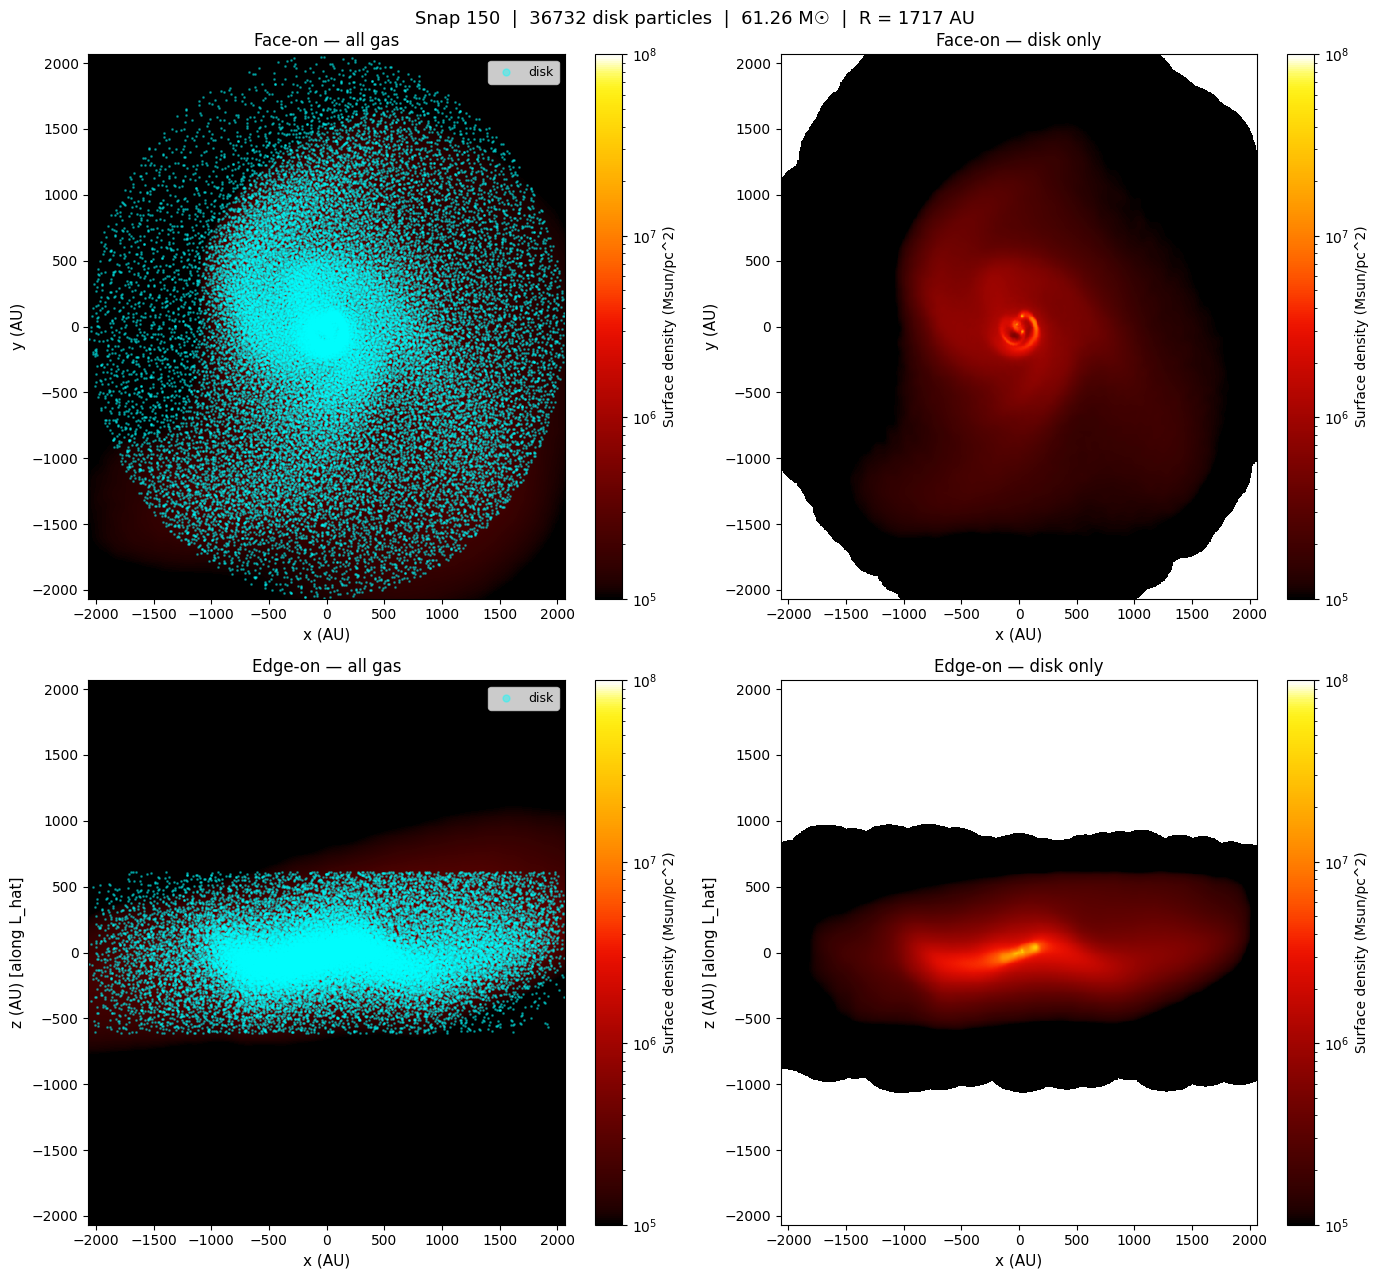

In [34]:
def rotation_matrix_to_z(L_hat):
    """Build rotation matrix R such that R @ L_hat = [0, 0, 1]."""
    z_hat  = np.array([0., 0., 1.])
    v      = np.cross(L_hat, z_hat)
    s      = np.linalg.norm(v)
    c      = np.dot(L_hat, z_hat)
    if s > 1e-10:
        vx  = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        rot = np.eye(3) + vx + vx @ vx * (1 - c) / s**2
    else:
        rot = np.eye(3) if c > 0 else -np.eye(3)
    return rot


def surface_density_maps(pdata, com, L_hat, is_disk,
                          image_box_kpc=2e-5, res=800):
    """
    Face-on and edge-on surface density maps.
    image_box_kpc : full width of the image [kpc]
    """
    rot       = rotation_matrix_to_z(L_hat)
    gas_dists = np.linalg.norm(pdata['Coordinates'] - com, axis=1)
    cut       = gas_dists < image_box_kpc

    # Centered, rotated positions (kpc)
    pos_rot   = (pdata['Coordinates'][cut] - com) @ rot.T
    mass_cut  = pdata['Masses'][cut]
    hsml_cut  = pdata['SmoothingLength'][cut]
    disk_cut  = is_disk[cut]

    center0   = np.zeros(3)
    extent_AU = image_box_kpc * kpc / AU
    ax_AU     = np.linspace(-extent_AU / 2, extent_AU / 2, res)
    X, Y      = np.meshgrid(ax_AU, ax_AU, indexing='ij')

    # ── Face-on ──────────────────────────────────────────────────────────────
    M_all  = Meshoid(pos_rot, mass_cut, hsml_cut)
    sig_all = M_all.SurfaceDensity(M_all.m * 1e10, center=center0,
                                    size=image_box_kpc, res=res) / 1e6  # Msun/pc^2

    # ── Edge-on: swap y ↔ z so Meshoid projects along original-y (disk plane) ─
    pos_edge = pos_rot[:, [0, 2, 1]]
    M_edge   = Meshoid(pos_edge, mass_cut, hsml_cut)
    sig_edge = M_edge.SurfaceDensity(M_edge.m * 1e10, center=center0,
                                      size=image_box_kpc, res=res) / 1e6

    # ── Disk-only ─────────────────────────────────────────────────────────────
    if disk_cut.sum() > 0:
        M_disk_fo = Meshoid(pos_rot[disk_cut], mass_cut[disk_cut], hsml_cut[disk_cut])
        sig_disk_fo = M_disk_fo.SurfaceDensity(M_disk_fo.m * 1e10, center=center0,
                                                size=image_box_kpc, res=res) / 1e6
        M_disk_eo = Meshoid(pos_edge[disk_cut], mass_cut[disk_cut], hsml_cut[disk_cut])
        sig_disk_eo = M_disk_eo.SurfaceDensity(M_disk_eo.m * 1e10, center=center0,
                                                size=image_box_kpc, res=res) / 1e6
    else:
        sig_disk_fo = sig_disk_eo = np.zeros((res, res))

    # ── Plotting ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 13))

    disk_pos_fo_AU = pos_rot[disk_cut] * kpc / AU
    disk_pos_eo_AU = pos_edge[disk_cut] * kpc / AU

    panels = [
        (axes[0, 0], sig_all,     disk_pos_fo_AU, 'Face-on — all gas'),
        (axes[0, 1], sig_disk_fo, disk_pos_fo_AU, 'Face-on — disk only'),
        (axes[1, 0], sig_edge,    disk_pos_eo_AU, 'Edge-on — all gas'),
        (axes[1, 1], sig_disk_eo, disk_pos_eo_AU, 'Edge-on — disk only'),
    ]

    for ax, sig, dpos, title in panels:
        vmin = 1e5 #sig[sig > 0].min() if sig.max() > 0 else 1
        vmax = 1e8 #sig.max() if sig.max() > 0 else 10
        im   = ax.pcolormesh(X, Y, sig, norm=colors.LogNorm(vmin=vmin, vmax=vmax), cmap='cet_fire')
        plt.colorbar(im, ax=ax, label='Surface density (Msun/pc^2)')
        if 'all' in title and disk_cut.sum() > 0:
            ax.scatter(dpos[:, 0], dpos[:, 1], s=1, alpha=0.4, c='cyan', label='disk')
            ax.legend(fontsize=9, markerscale=5)
        ax.set_xlabel('x (AU)', fontsize=11)
        ax.set_ylabel('y (AU)' if 'Face' in title else 'z (AU) [along L_hat]', fontsize=11)
        ax.set_title(title, fontsize=12)

    fig.suptitle(f'Snap {snap_num}  |  {props["n_disk_particles"]} disk particles  |  '
                 f'{props["M_disk_Msun"]:.2f} M☉  |  R = {props["R_disk_AU"]:.0f} AU', fontsize=13)
    plt.tight_layout()
    plt.show()
    return fig


fig_maps = surface_density_maps(pdata, com, L_hat, is_disk,
                                 image_box_kpc=r_max_kpc * 2, res=600)


## Time series over all snapshots

Loops over all snapshots, runs `identify_disk` with the same parameters, and saves disk properties to a pickle file.

**Note**: the same parameters tuned above are used here — re-run after adjusting them.


In [35]:
snap_pattern = os.path.join(path, sim, "snapshot_*.hdf5")
snap_paths   = sorted(glob.glob(snap_pattern))
print(f"Found {len(snap_paths)} snapshots")

save_dir  = "/mnt/home/skhullar/analysis/popIII_analysis/data/"
save_file = os.path.join(save_dir, "disk_properties.pkl")
os.makedirs(save_dir, exist_ok=True)

results = []

for snap_path in tqdm(snap_paths):
    snap_num_i = int(os.path.basename(snap_path).replace('snapshot_', '').replace('.hdf5', ''))

    try:
        hdr, pd_i, sd_i, fsd_i, _, _ = get_snap_data_hybrid(
            sim, path, snap_num_i, snapshot_suffix='', snapdir=False,
            refinement_tag=False, verbose=False, custom_gas_fields=gas_fields)
        hdr, pd_i, sd_i, fsd_i = convert_units_to_physical(hdr, pd_i, sd_i, fsd_i)
    except Exception as e:
        print(f"Snap {snap_num_i}: load error — {e}")
        continue

    # Time in Myr (cosmological conversion)
    try:
        time_Myr = convert_scale_factor_to_time(hdr['Time'], pd_i)
    except Exception:
        time_Myr = hdr['Time']   # fall back to scale factor if conversion fails

    try:
        is_disk_i, com_i, L_hat_i, r_cyl_i, z_i, v_phi_i, vK_i = identify_disk(
            pd_i, sd_i,
            r_search_kpc      = r_search_kpc,
            r_max_kpc         = r_max_kpc,
            rho_threshold_cgs = rho_threshold_cgs,
            aspect_ratio      = aspect_ratio,
            f_kep             = f_kep,
        )
        props_i = compute_disk_properties(pd_i, sd_i, is_disk_i, r_cyl_i, z_i, L_hat_i)
    except Exception as e:
        print(f"Snap {snap_num_i}: disk ID error — {e}")
        continue

    props_i['snap_num']  = snap_num_i
    props_i['time_Myr']  = time_Myr
    results.append(props_i)

with open(save_file, 'wb') as f:
    pickle.dump(results, f)

print(f"\nSaved {len(results)} snapshots → {save_file}")


Found 318 snapshots


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 318/318 [01:06<00:00,  4.79it/s]


Saved 318 snapshots → /mnt/home/skhullar/analysis/popIII_analysis/data/disk_properties.pkl


## Time series plots

Snapshots with disk detected: 318 / 318


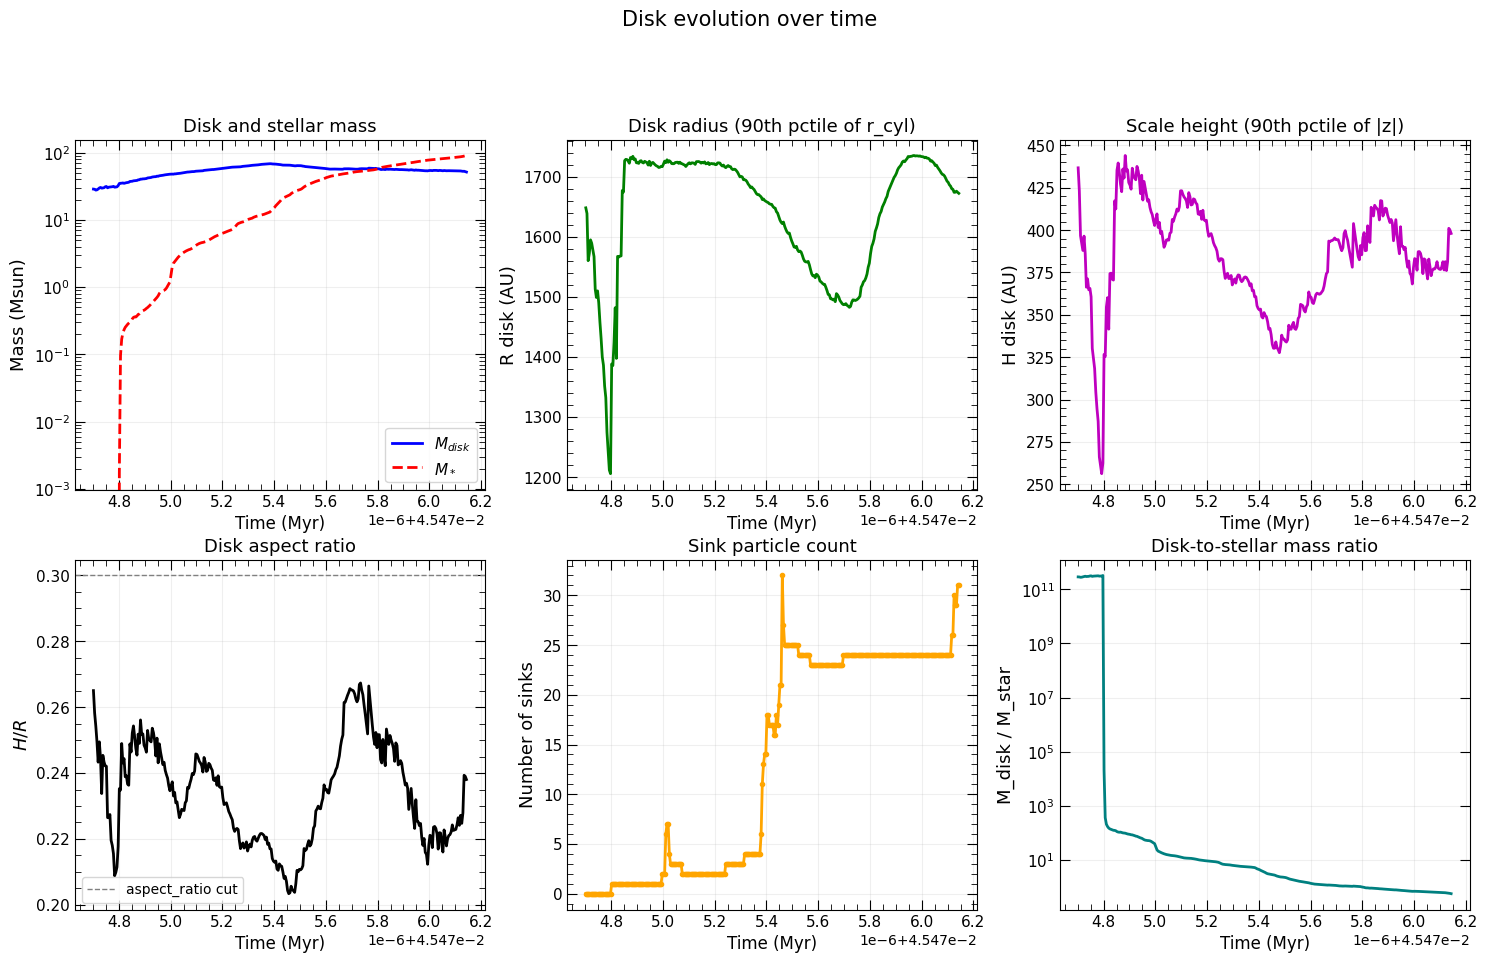

In [36]:
with open("/mnt/home/skhullar/analysis/popIII_analysis/data/disk_properties.pkl", 'rb') as f:
    results = pickle.load(f)

# Filter to snapshots where disk was found
res_disk = [r for r in results if r['n_disk_particles'] > 0]
print(f"Snapshots with disk detected: {len(res_disk)} / {len(results)}")

times    = np.array([r['time_Myr']  for r in res_disk])
M_disk   = np.array([r['M_disk_Msun']   for r in res_disk])
M_stars  = np.array([r['M_stars_Msun']  for r in res_disk])
R_disk   = np.array([r['R_disk_AU']     for r in res_disk])
H_disk   = np.array([r['H_disk_AU']     for r in res_disk])
H_over_R = np.array([r['H_over_R']      for r in res_disk])
n_stars  = np.array([r['n_stars']       for r in res_disk])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

kw = dict(lw=2)

axes[0, 0].plot(times, M_disk,  'b-',  label='$M_{disk}$', **kw)
axes[0, 0].plot(times, M_stars, 'r--', label='$M_*$',    **kw)
axes[0, 0].set_ylabel('Mass (Msun)', fontsize=13)
axes[0, 0].set_yscale('log')
axes[0, 0].legend(fontsize=11)
axes[0, 0].set_title('Disk and stellar mass', fontsize=13)

axes[0, 1].plot(times, R_disk, 'g-', **kw)
axes[0, 1].set_ylabel('R disk (AU)', fontsize=13)
axes[0, 1].set_title('Disk radius (90th pctile of r_cyl)', fontsize=13)

axes[0, 2].plot(times, H_disk, 'm-', **kw)
axes[0, 2].set_ylabel('H disk (AU)', fontsize=13)
axes[0, 2].set_title('Scale height (90th pctile of |z|)', fontsize=13)

axes[1, 0].plot(times, H_over_R, 'k-', **kw)
axes[1, 0].set_ylabel('$H / R$', fontsize=13)
axes[1, 0].set_title('Disk aspect ratio', fontsize=13)
axes[1, 0].axhline(0.3, ls='--', color='gray', lw=1, label='aspect_ratio cut')
axes[1, 0].legend(fontsize=10)

axes[1, 1].plot(times, n_stars, 'orange', marker='.', ls='-', **kw)
axes[1, 1].set_ylabel('Number of sinks', fontsize=13)
axes[1, 1].set_title('Sink particle count', fontsize=13)

axes[1, 2].plot(times, M_disk / np.maximum(M_stars, 1e-10), 'teal', **kw)
axes[1, 2].set_ylabel('M_disk / M_star', fontsize=13)
axes[1, 2].set_title('Disk-to-stellar mass ratio', fontsize=13)
axes[1, 2].set_yscale('log')

for ax in axes.flat:
    ax.set_xlabel('Time (Myr)', fontsize=12)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', right=True, top=True, labelsize=11)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.grid(True, alpha=0.2)

fig.suptitle('Disk evolution over time', fontsize=15, y=1.01)
#plt.tight_layout()
plt.show()
